# Web Scraping Project



## Step 1: Install Libraries


In [1]:
!pip install requests beautifulsoup4 pandas

## Step 2: Import Libraries & Scrape Data

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

books = []
page = 1

while True:
    url = f"http://books.toscrape.com/catalogue/page-{page}.html"
    response = requests.get(url)

    # Agar page nahi mila toh band karo
    if response.status_code != 200:
        break

    soup = BeautifulSoup(response.text, "html.parser")

    for book in soup.find_all("article", class_="product_pod"):
        title = book.find("h3").find("a")["title"]
        price = book.find("p", class_="price_color").text.strip()
        rating = book.find("p", class_="star-rating")["class"][1]

        books.append({
            "Title": title,
            "Price": price,
            "Rating": rating
        })

    print(f"✅ Page {page} done — Books so far: {len(books)}")
    page += 1
    time.sleep(0.5)  # Website pe load kam karne ke liye

df = pd.DataFrame(books)
print(f"\n🎉 Total Books Scraped: {len(df)}")
df.head(10)

✅ Page 1 done — Books so far: 20
✅ Page 2 done — Books so far: 40
✅ Page 3 done — Books so far: 60
✅ Page 4 done — Books so far: 80
✅ Page 5 done — Books so far: 100
✅ Page 6 done — Books so far: 120
✅ Page 7 done — Books so far: 140
✅ Page 8 done — Books so far: 160
✅ Page 9 done — Books so far: 180
✅ Page 10 done — Books so far: 200
✅ Page 11 done — Books so far: 220
✅ Page 12 done — Books so far: 240
✅ Page 13 done — Books so far: 260
✅ Page 14 done — Books so far: 280
✅ Page 15 done — Books so far: 300
✅ Page 16 done — Books so far: 320
✅ Page 17 done — Books so far: 340
✅ Page 18 done — Books so far: 360
✅ Page 19 done — Books so far: 380
✅ Page 20 done — Books so far: 400
✅ Page 21 done — Books so far: 420
✅ Page 22 done — Books so far: 440
✅ Page 23 done — Books so far: 460
✅ Page 24 done — Books so far: 480
✅ Page 25 done — Books so far: 500
✅ Page 26 done — Books so far: 520
✅ Page 27 done — Books so far: 540
✅ Page 28 done — Books so far: 560
✅ Page 29 done — Books so far: 58

,Title,Price,Rating
0,A Light in the Attic,Â£51.77,Three
1,Tipping the Velvet,Â£53.74,One
2,Soumission,Â£50.10,One
3,Sharp Objects,Â£47.82,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,Five
5,The Requiem Red,Â£22.65,One
6,The Dirty Little Secrets of Getting Your Dream...,Â£33.34,Four
7,The Coming Woman: A Novel Based on the Life of...,Â£17.93,Three
8,The Boys in the Boat: Nine Americans and Their...,Â£22.60,Four
9,The Black Maria,Â£52.15,One


In [3]:
df.head(20)

,Title,Price,Rating
0,A Light in the Attic,Â£51.77,Three
1,Tipping the Velvet,Â£53.74,One
2,Soumission,Â£50.10,One
3,Sharp Objects,Â£47.82,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,Five
5,The Requiem Red,Â£22.65,One
6,The Dirty Little Secrets of Getting Your Dream...,Â£33.34,Four
7,The Coming Woman: A Novel Based on the Life of...,Â£17.93,Three
8,The Boys in the Boat: Nine Americans and Their...,Â£22.60,Four
9,The Black Maria,Â£52.15,One


## Step 3: Data Cleaning & Custom Dataset Creation

In this step, we clean the raw scraped data:
- Removed currency symbols from Price column
- Converted Rating from words to numbers (1-5)
- Added Price Category column (Cheap, Medium, Expensive)
- This creates a custom dataset ready for analysis





In [4]:
# Remove £ sign from Price and convert to number
df["Price"] = df["Price"].str.replace("Â£", "").str.replace("£", "").astype(float)

# Convert Rating from words to numbers
rating_map = {
    "One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5
}
df["Rating"] = df["Rating"].map(rating_map)

# Add Price Category column
df["Price_Category"] = df["Price"].apply(
    lambda x: "Cheap" if x < 20 else ("Medium" if x < 40 else "Expensive")
)

print(" Data Cleaning Complete!")
print(f"\nTotal Books: {len(df)}")
print("\nData Types:")
print(df.dtypes)
print("\nPreview:")
df.head(10)

 Data Cleaning Complete!

Total Books: 1000

Data Types:
Title              object
Price             float64
Rating              int64
Price_Category     object
dtype: object

Preview:


,Title,Price,Rating,Price_Category
0,A Light in the Attic,51.77,3,Expensive
1,Tipping the Velvet,53.74,1,Expensive
2,Soumission,50.10,1,Expensive
3,Sharp Objects,47.82,4,Expensive
4,Sapiens: A Brief History of Humankind,54.23,5,Expensive
5,The Requiem Red,22.65,1,Medium
6,The Dirty Little Secrets of Getting Your Dream...,33.34,4,Medium
7,The Coming Woman: A Novel Based on the Life of...,17.93,3,Cheap
8,The Boys in the Boat: Nine Americans and Their...,22.60,4,Medium
9,The Black Maria,52.15,1,Expensive


## Step 4: Save Data to CSV File

In this step, we export the cleaned dataset to a CSV file.
This file will be used for further analysis and visualization.

In [5]:
# Save data to CSV file
df.to_csv("books_data.csv", index=False)
print("✅ File Saved Successfully!")
print(f"Total Records: {len(df)}")

✅ File Saved Successfully!
Total Records: 1000


# Exploratory Data Analysis (EDA)
##  Task 2
### Dataset: Books Data (Scraped from books.toscrape.com)

## Step 1: Questions Before Analysis

1. What is the average price of all books?
2. Which rating is most common among books?
3. Which price category has the most books?
4. Are highly rated books more expensive?
5. What is the price range of books?

## Step 2: Explore Data Structure

In [6]:
# Explore data structure
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nBasic Statistics:")
df.describe()

Shape: (1000, 4)

Columns: ['Title', 'Price', 'Rating', 'Price_Category']

Data Types:
Title              object
Price             float64
Rating              int64
Price_Category     object
dtype: object

Basic Statistics:


,Price,Rating
count,1000.00000,1000.000000
mean,35.07035,2.923000
std,14.44669,1.434967
min,10.00000,1.000000
25%,22.10750,2.000000
50%,35.98000,3.000000
75%,47.45750,4.000000
max,59.99000,5.000000


## Step 3: Identify Trends, Patterns and Anomalies

In [ ]:
# Trends & Patterns
print("Most Common Rating:", df["Rating"].mode()[0])
print("Most Common Category:", df["Price_Category"].mode()[0])
print("Expensive Books:", len(df[df["Price_Category"]=="Expensive"]))
print("Cheap Books:", len(df[df["Price_Category"]=="Cheap"]))
print("Medium Books:", len(df[df["Price_Category"]=="Medium"]))

# Anomalies - check for outliers
print("\nPrice Outliers (above 55):")
print(df[df["Price"] > 55][["Title","Price"]].head())

Most Common Rating: 1
Most Common Category: Expensive
Expensive Books: 403
Cheap Books: 196
Medium Books: 401

Price Outliers (above 55):
                                                Title  Price
15  Our Band Could Be Your Life: Scenes from the A...  57.25
40                     Slow States of Collapse: Poems  57.31
56                    The Secret of Dreadwillow Carse  56.13
57  The Pioneer Woman Cooks: Dinnertime: Comfort C...  56.41
58                                The Past Never Ends  56.50


## Step 4: Test Hypotheses and Validate Assumptions

/tmp/ipykernel_3562/517031580.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Rating", data=df, ax=axes[1], palette="viridis")


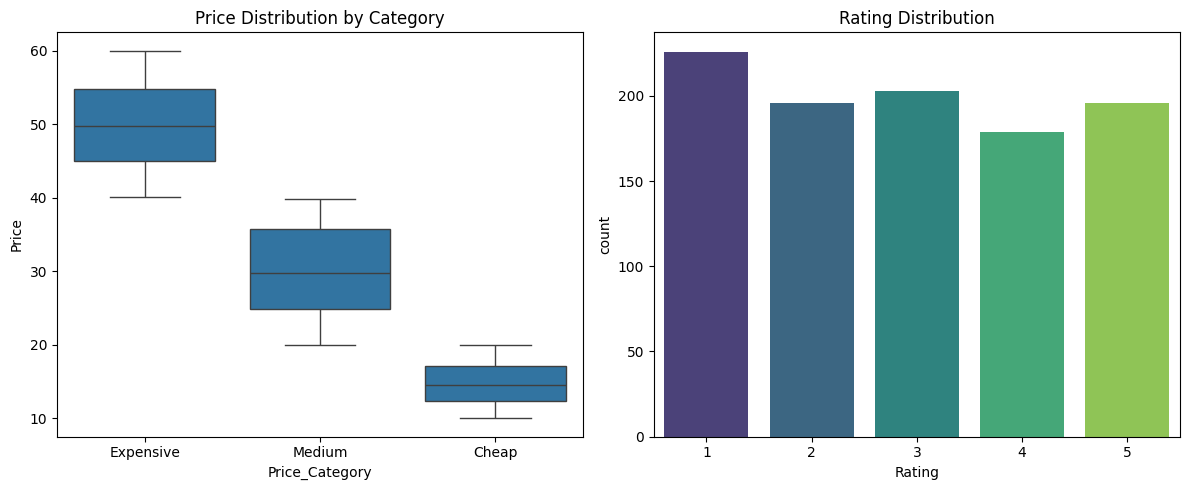

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Graph 1: Price Category vs Rating
sns.boxplot(x="Price_Category", y="Price", data=df, ax=axes[0])
axes[0].set_title("Price Distribution by Category")

# Graph 2: Rating Distribution
sns.countplot(x="Rating", data=df, ax=axes[1], palette="viridis")
axes[1].set_title("Rating Distribution")

plt.tight_layout()
plt.show()

## Step 5: Detect Potential Data Issues

In [ ]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Check price anomalies
print("\nBooks with Price below 15:")
print(df[df["Price"] < 15][["Title", "Price"]].head())

print("\nBooks with Price above 55:")
print(df[df["Price"] > 55][["Title", "Price"]].head())

# Summary
print("\nData Issues Summary:")
print(f"Total Missing Values: {df.isnull().sum().sum()}")
print(f"Total Duplicates: {df.duplicated().sum()}")

Missing Values:
Title             0
Price             0
Rating            0
Price_Category    0
dtype: int64

Duplicate Rows: 0

Books with Price below 15:
                                                Title  Price
10     Starving Hearts (Triangular Trade Trilogy, #1)  13.99
20                                        In Her Wake  12.84
47            Untitled Collection: Sabbath Poems 2014  14.27
80  Princess Jellyfish 2-in-1 Omnibus, Vol. 01 (Pr...  13.61
81   Princess Between Worlds (Wide-Awake Princess #5)  13.34

Books with Price above 55:
                                                Title  Price
15  Our Band Could Be Your Life: Scenes from the A...  57.25
40                     Slow States of Collapse: Poems  57.31
56                    The Secret of Dreadwillow Carse  56.13
57  The Pioneer Woman Cooks: Dinnertime: Comfort C...  56.41
58                                The Past Never Ends  56.50

Data Issues Summary:
Total Missing Values: 0
Total Duplicates: 0
